### Load dataset

In [10]:
import os
import sys
import math
from tqdm import tqdm
from pathlib import Path
from typing import Any, overload
from collections import defaultdict

import torch
import wandb
import numpy as np
from torch import nn, Tensor
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.optim import Optimizer, AdamW
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import LRScheduler, LambdaLR

from src.models import MAE_ViT
from src import configs as cfg
from src.utils import setup_seed
from src.plotting import plt_sample
from src import dataset, metrics, timing

In [18]:
path = "checkpoints/finetuned/vit_epoch500.pt"

In [19]:
chkpt = torch.load(path, weights_only=False)
traom_cfg = chkpt["train_cfg"]
if "mask_rec_loss_weight" in traom_cfg:
    del traom_cfg["mask_rec_loss_weight"]
train_cfg = cfg.TrainingConfig(**traom_cfg)
model_cfg = cfg.ModelConfig(**chkpt["model_cfg"])
model = MAE_ViT.from_config(model_cfg, True)
model.load_state_dict(chkpt["model"])

number of parameters: 14.0M


<All keys matched successfully>

In [20]:
loaders = dataset.mk_semi_supervised_data_loaders(train_cfg)

In [21]:
import plotly.express as px
from src import plotting

def plt_recon_imgs(model: nn.Module, loader: DataLoader):
    x, y_true = next(iter(loader))
    x = dataset.preprocess_imgs(x)[:plotting.N_IMGS_TO_PLT]
    x_hat, mask = model(x, 0.65)
    x_hat_img = x_hat[:, :1]
    mask = mask[:, :1]
    x_hat_img = x_hat_img * mask + x * (1 - mask)
    img = torch.cat(
        [
            x * (1 - mask),
            x_hat_img,
            x,
        ],
        dim=0,
    )
    # img = img * dataset.STD + dataset.MEAN 
    np_imgs = (
        img
        .detach()
        .cpu()
        .numpy()
        .squeeze()
    )
    fig = px.imshow(
        np_imgs,
        facet_col=0,
        facet_col_wrap=plotting.N_IMGS_TO_PLT,
        color_continuous_scale="rainbow",
    )
    fig.show()

plt_recon_imgs(model, loaders["train"])

train
n samples with seg: tensor(18, device='cuda:0') torch.Size([64])


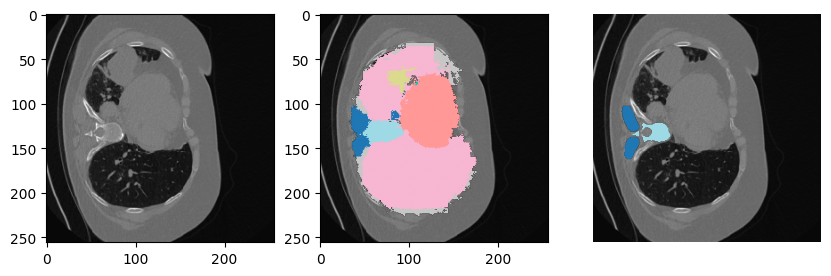

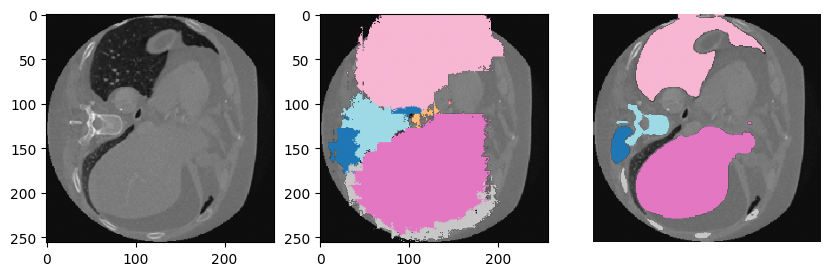

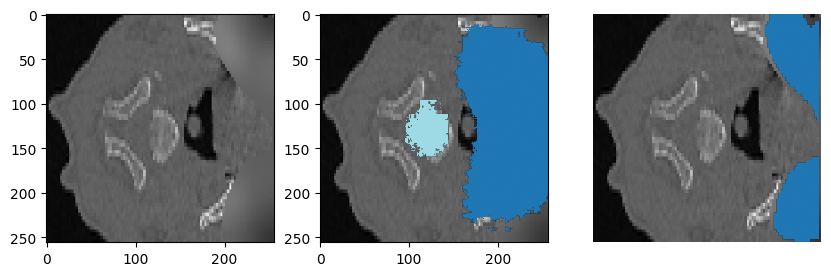

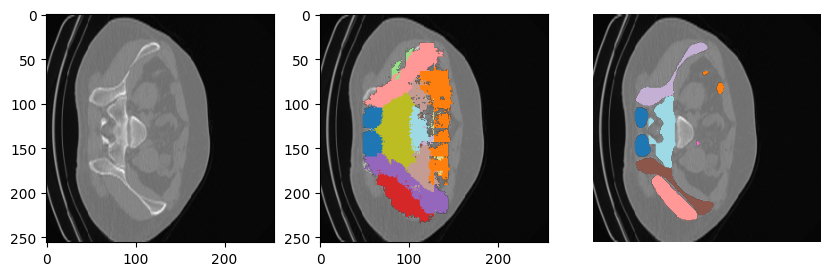

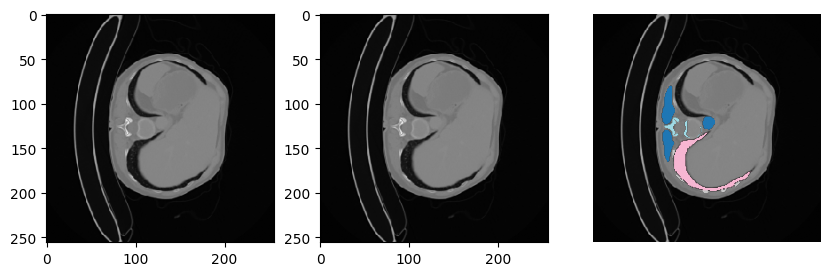

valid
n samples with seg: tensor(15, device='cuda:0') torch.Size([64])


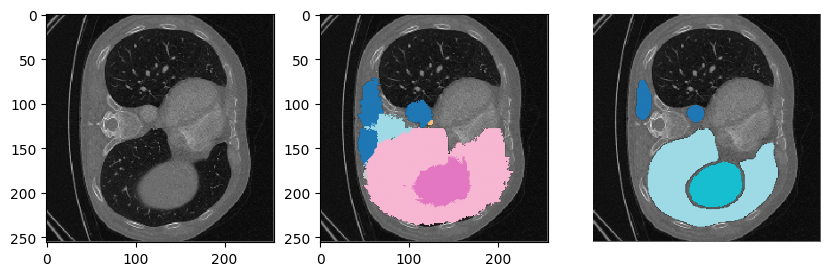

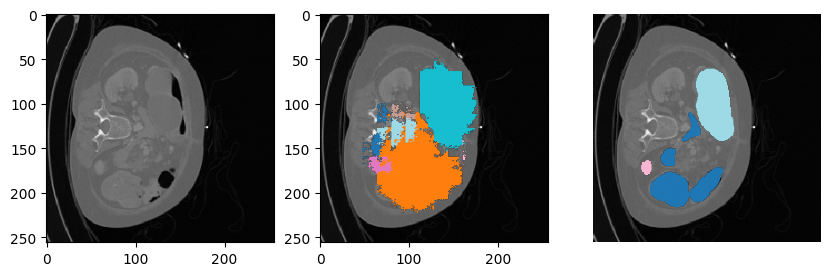

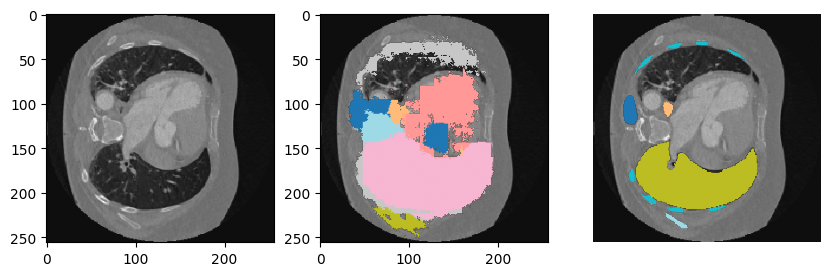

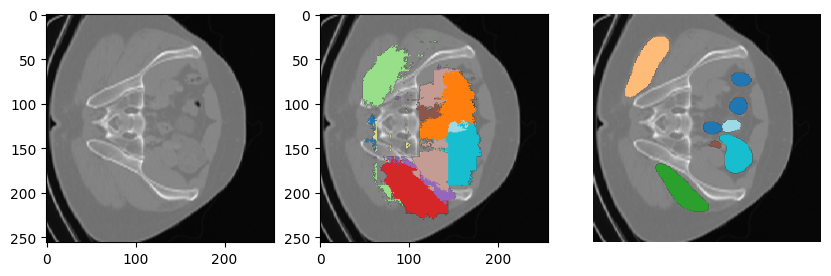

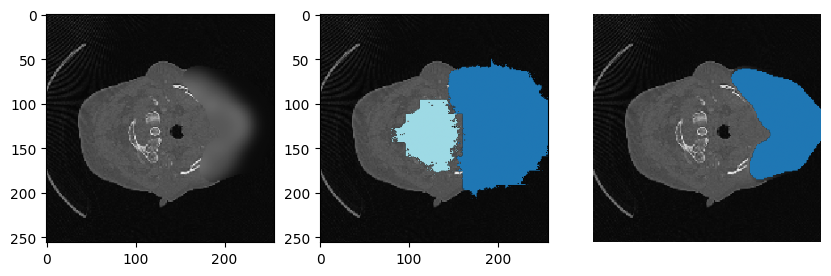

In [22]:
print("train")
plotting.plt_model_preds(model, loaders["train"], plt_recon=False, mask_ratio=0)
print("valid")
plotting.plt_model_preds(model, loaders["valid"], plt_recon=False, mask_ratio=0)

### Make submission

In [ ]:
from tqdm import tqdm

import numpy as np
import pandas as pd
from torch.utils.data import DataLoader

@torch.no_grad
def mk_submission(model: nn.Module, x_test: Tensor, batch_size: int=128):
    test_loader = DataLoader(x_test, batch_size=batch_size, shuffle=False)
    predictions = []

    for image in tqdm(test_loader) :
        image = image.to(device=device)
        y_pred_logits = model(image)
        pred = torch.argmax(y_pred_logits, dim=1)
        print(pred.shape)
        predictions.append(pred.cpu().numpy())

    predictions = np.concat(predictions)
    print("n unique values:", len(np.unique(predictions)))
    df = pd.DataFrame(predictions.reshape((predictions.shape[0], -1))).T
    df.index = [f"Pixel {i}" for i in df.index]
    df.columns = [f"{col}.png" for col in df.columns]
    df.to_csv("submission.csv")

mk_submission(model, x_test)

NameError: name 'x_test' is not defined

: 